Touchpoint Columns:
['touchpoint_1', 'touchpoint_2', 'touchpoint_3', 'touchpoint_4', 'touchpoint_5', 'touchpoint_6', 'touchpoint_7', 'touchpoint_8', 'touchpoint_9', 'touchpoint_10']
Total Paths: 32000

Transition Matrix
                    Affiliate Blog  App Push  CONVERSION  Community WhatsApp  \
Affiliate Blog            0.014059  0.148825    0.031332            0.026913   
App Push                  0.020523  0.062039    0.102012            0.022535   
CONVERSION                0.000000  0.000000    0.000000            0.000000   
Community WhatsApp        0.038736  0.128891    0.035508            0.007378   
Email                     0.019908  0.124321    0.107685            0.019978   

                       Email  Influencer Post      NULL  Organic Social  \
Affiliate Blog      0.132155              0.0  0.134163             0.0   
App Push            0.129779              0.0  0.266197             0.0   
CONVERSION          0.000000              0.0  0.000000             0.0   

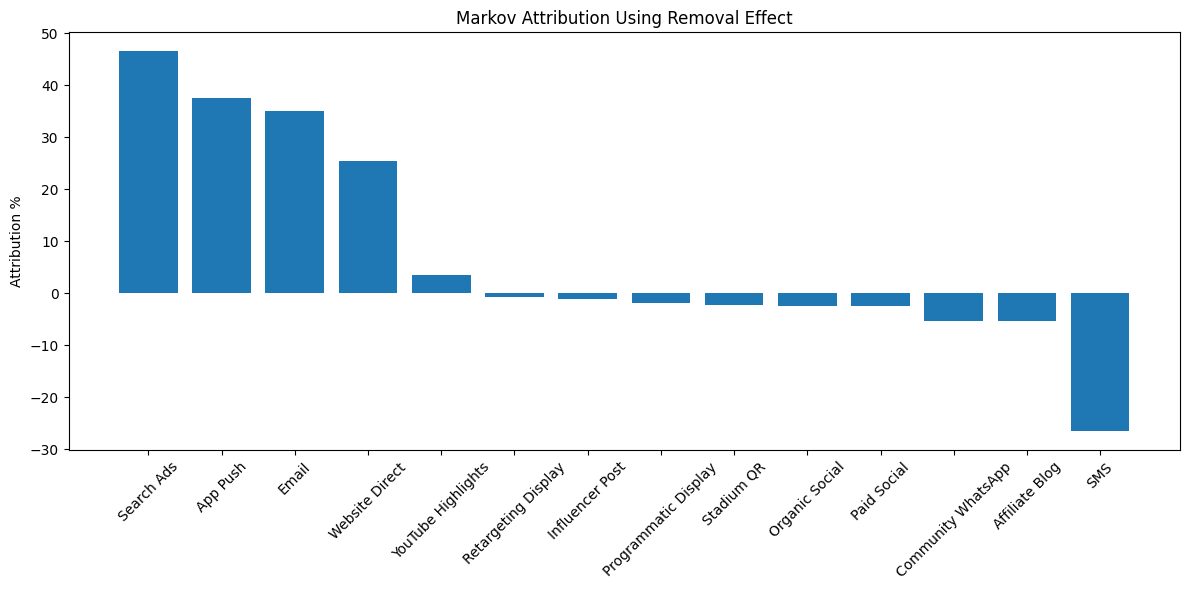


Top Performing Channels
                 Channel  Attribution_%
10            Search Ads      46.523564
1               App Push      37.534206
3                  Email      35.127401
12        Website Direct      25.423068
13    YouTube Highlights       3.542659
8    Retargeting Display      -0.701618
4        Influencer Post      -1.167103
7   Programmatic Display      -1.823933
11            Stadium QR      -2.205365
5         Organic Social      -2.495047


In [8]:
# =====================================================
# MARKOV CHAIN ATTRIBUTION MODEL
# REMOVAL EFFECT METHOD
# =====================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns # Import seaborn

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("/content/dataset_3_sports_marketing_mta_paths.xlsx")

# =====================================================
# IDENTIFY TOUCHPOINT COLUMNS
# =====================================================

touch_cols = [c for c in df.columns if "touchpoint_" in c]

print("Touchpoint Columns:")
print(touch_cols)

# =====================================================
# CREATE PATHS
# =====================================================

paths = []

for _, row in df.iterrows():

    journey = []

    for col in touch_cols:

        if pd.notna(row[col]):

            tp = str(row[col]).strip()

            if tp != "":
                journey.append(tp)

    if len(journey) == 0:
        continue

    journey.insert(0, "START")

    if row["converted"] == 1:
        journey.append("CONVERSION")
    else:
        journey.append("NULL")

    paths.append(journey)

print("Total Paths:", len(paths))

# =====================================================
# BUILD TRANSITION COUNTS
# =====================================================

transition_counts = defaultdict(int)

for path in paths:

    for i in range(len(path)-1):

        source = path[i]
        target = path[i+1]

        transition_counts[(source,target)] += 1

# =====================================================
# TRANSITION MATRIX
# =====================================================

states = set()

for s,t in transition_counts.keys():

    states.add(s)
    states.add(t)

states = sorted(list(states))

transition_matrix = pd.DataFrame(
    0,
    index=states,
    columns=states
)

for (s,t),count in transition_counts.items():

    transition_matrix.loc[s,t] = count

transition_matrix = transition_matrix.div(
    transition_matrix.sum(axis=1),
    axis=0
).fillna(0)

print("\nTransition Matrix")
print(transition_matrix.head())

# =====================================================
# CONVERSION PROBABILITY FUNCTION
# =====================================================

def calculate_conversion_probability(matrix):

    states = matrix.index.tolist()

    absorbing = ["CONVERSION","NULL"]

    transient = [
        s for s in states
        if s not in absorbing
    ]

    Q = matrix.loc[
        transient,
        transient
    ].values

    R = matrix.loc[
        transient,
        absorbing
    ].values

    I = np.eye(len(Q))

    try:

        N = np.linalg.inv(I - Q)

    except:

        return 0

    B = np.dot(N,R)

    start_idx = transient.index("START")

    conversion_prob = B[start_idx,0]

    return conversion_prob

# =====================================================
# BASELINE CONVERSION PROBABILITY
# =====================================================

baseline_conversion = calculate_conversion_probability(
    transition_matrix
)

print("\nBaseline Conversion Probability")
print(round(baseline_conversion,4))

# =====================================================
# MARKOV REMOVAL EFFECT
# =====================================================

channels = [
    c for c in states
    if c not in ["START","CONVERSION","NULL"]
]

removal_effects = {}

for channel in channels:

    modified = transition_matrix.copy()

    modified.loc[channel,:] = 0

    for state in modified.index:

        if channel in modified.columns:

            modified.loc[state,channel] = 0

    row_sums = modified.sum(axis=1)

    modified = modified.div(
        row_sums.replace(0,1),
        axis=0
    )

    new_prob = calculate_conversion_probability(
        modified
    )

    removal_effect = (
        baseline_conversion - new_prob
    )

    removal_effects[channel] = removal_effect

# =====================================================
# ATTRIBUTION WEIGHTS
# =====================================================

removal_df = pd.DataFrame({
    "Channel": removal_effects.keys(),
    "Removal_Effect": removal_effects.values()
})

removal_df = removal_df.sort_values(
    "Removal_Effect",
    ascending=False
)

total_effect = removal_df["Removal_Effect"].sum()

removal_df["Attribution_%"] = (
    removal_df["Removal_Effect"]
    /
    total_effect
)*100

print("\nMARKOV ATTRIBUTION RESULTS")
print(removal_df)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(12,6))

plt.bar(
    removal_df["Channel"],
    removal_df["Attribution_%"]
)

plt.xticks(rotation=45)

plt.title(
    "Markov Attribution Using Removal Effect"
)

plt.ylabel("Attribution %")

plt.tight_layout()

plt.show()

# =====================================================
# TOP CHANNELS
# =====================================================

print("\nTop Performing Channels")

print(
    removal_df[
        ["Channel","Attribution_%"]
    ].head(10)
)

### Visualize the Markov Chain as a Network Graph

This visualization represents the Markov chain as a directed graph. Nodes are the touchpoints (including 'START', 'CONVERSION', and 'NULL'), and edges represent the transitions between them. The thickness of the edges can be used to indicate the transition probability.

To keep the graph readable, we'll only plot transitions with a probability above a certain threshold (e.g., 0.01).

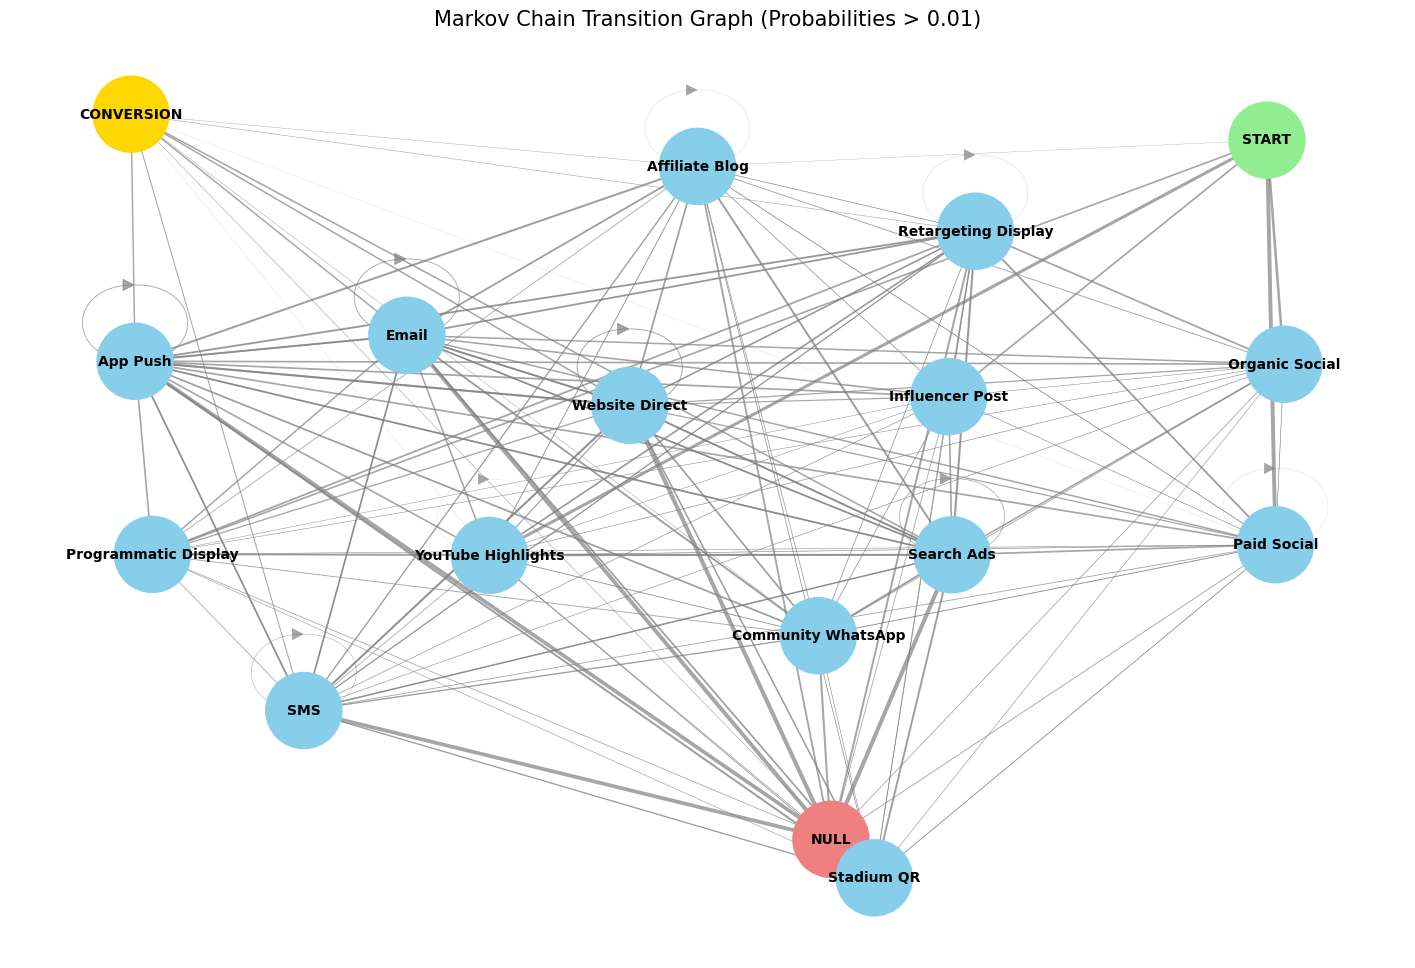

In [4]:
G = nx.DiGraph()

# Add nodes
for state in states:
    G.add_node(state)

# Add edges with probabilities as weights
for source in transition_matrix.index:
    for target in transition_matrix.columns:
        prob = transition_matrix.loc[source, target]
        if prob > 0.01: # Filter out very low probability transitions for clarity
            G.add_edge(source, target, weight=prob)

# Define node colors based on type
node_colors = []
for node in G.nodes():
    if node == 'START':
        node_colors.append('lightgreen')
    elif node == 'CONVERSION':
        node_colors.append('gold')
    elif node == 'NULL':
        node_colors.append('lightcoral')
    else:
        node_colors.append('skyblue')

# Define edge widths based on probability
edges = G.edges()
weights = [G[u][v]['weight'] * 10 for u,v in edges] # Scale weights for better visibility

plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, k=0.7, iterations=50) # Use spring layout for better node separation

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, arrowsize=20, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

edge_labels = nx.get_edge_attributes(G, 'weight')
# Filter edge labels to only show for thicker edges and format to 2 decimal places
significant_edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items() if v > 0.01}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=significant_edge_labels, font_color='red', font_size=8)

plt.title('Markov Chain Transition Graph (Probabilities > 0.01)', size=15)
plt.axis('off')
plt.show()

### Pie Chart of Positive Channel Attribution Percentages

This pie chart visualizes the proportional attribution of only those channels that have a positive removal effect. It helps in understanding the share of conversion contributed by each effective channel.

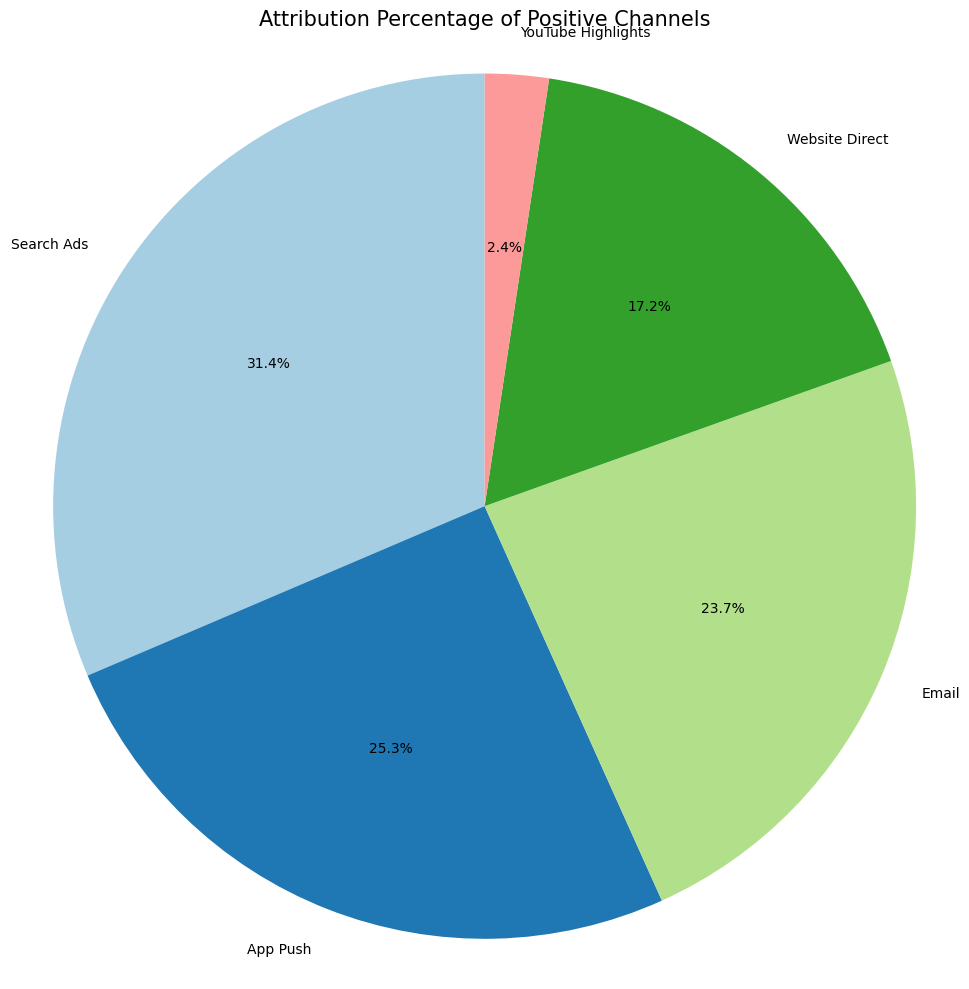

In [5]:
# Filter for channels with positive attribution percentages
positive_attribution_df = removal_df[removal_df['Attribution_%'] > 0]

plt.figure(figsize=(10, 10))
plt.pie(
    positive_attribution_df['Attribution_%'],
    labels=positive_attribution_df['Channel'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors
)
plt.title('Attribution Percentage of Positive Channels', size=15)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### Bar Chart of Raw Removal Effect

This bar chart directly displays the 'Removal_Effect' value for each channel. This helps to see the absolute impact on the baseline conversion probability when a channel is removed, including both positive and negative effects.

/tmp/ipykernel_1739/1090387727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


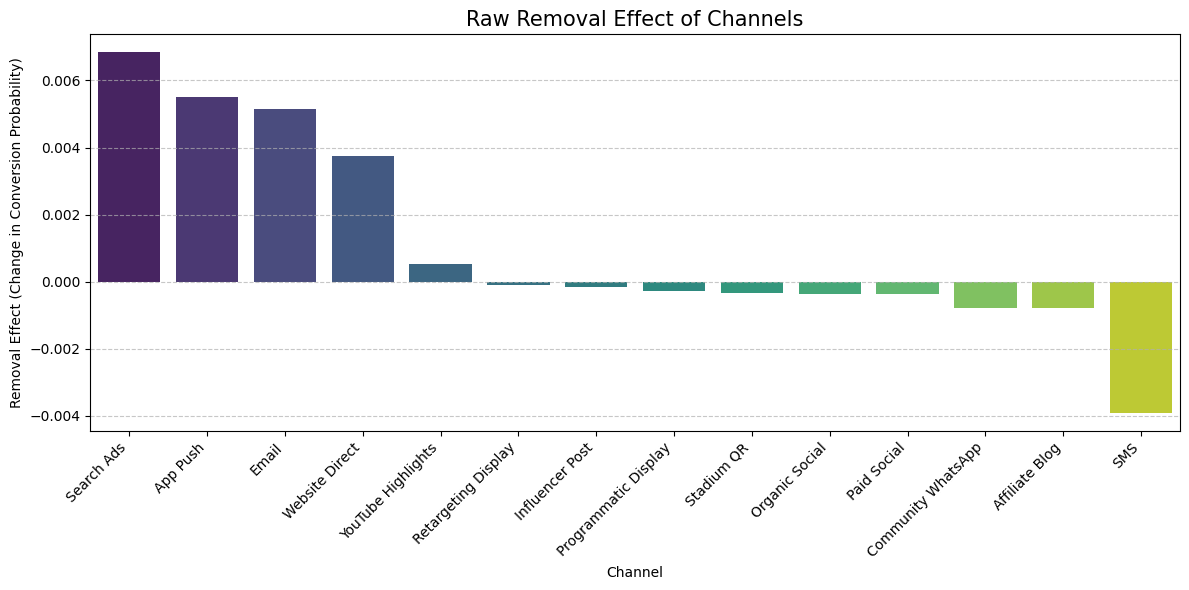

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x='Channel',
    y='Removal_Effect',
    data=removal_df.sort_values('Removal_Effect', ascending=False),
    palette='viridis'
)
plt.xticks(rotation=45, ha='right')
plt.title('Raw Removal Effect of Channels', size=15)
plt.xlabel('Channel')
plt.ylabel('Removal Effect (Change in Conversion Probability)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Heatmap of Transition Probabilities

This heatmap visualizes the `transition_matrix`, showing the probability of moving from one state (row) to another (column). Darker colors indicate higher transition probabilities, making it easier to spot strong connections between touchpoints.

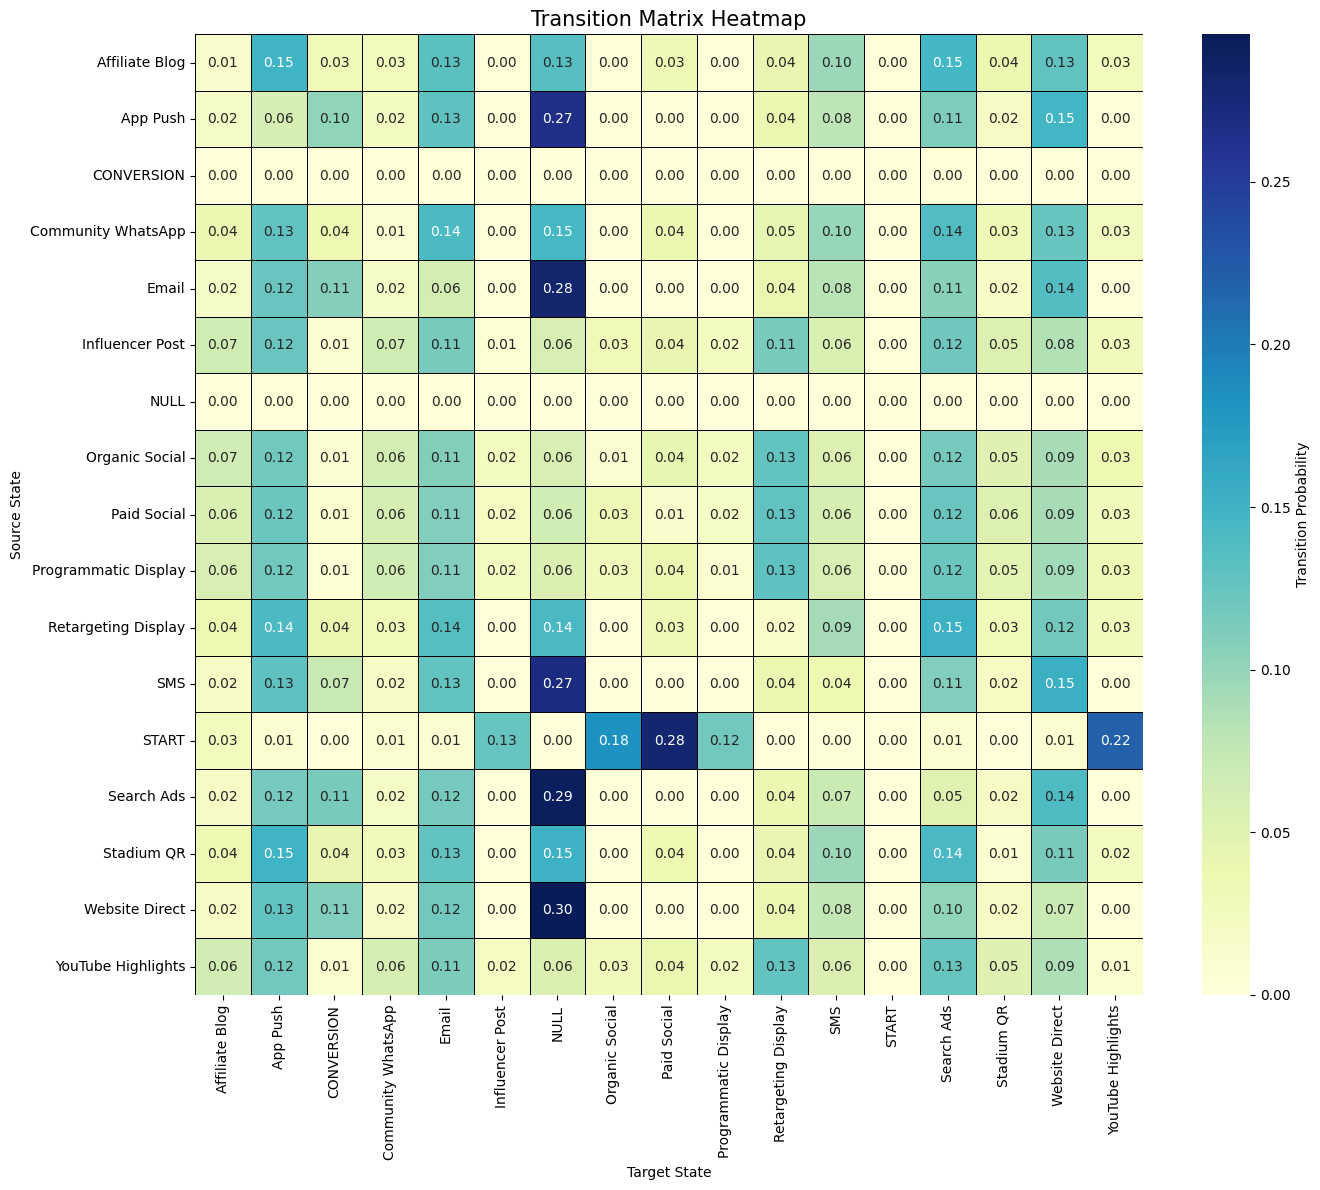

In [10]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    transition_matrix,
    annot=True,
    fmt=".2f", # Format annotations to two decimal places
    cmap="YlGnBu", # Color map
    linewidths=.5, # Add lines between cells
    linecolor='black',
    cbar_kws={'label': 'Transition Probability'}
)
plt.title('Transition Matrix Heatmap', size=15)
plt.xlabel('Target State')
plt.ylabel('Source State')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Bar Chart of Transition Probabilities from a Selected State

This bar chart visualizes the probability of transitioning from a specific 'Source State' to all other possible 'Target States'. This helps in quickly identifying the most likely next steps in a customer's journey after interacting with a particular touchpoint. You can easily modify `source_state` in the code to explore transitions from other channels.

/tmp/ipykernel_1739/643646081.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_probs.index, y=filtered_probs.values, palette='viridis')


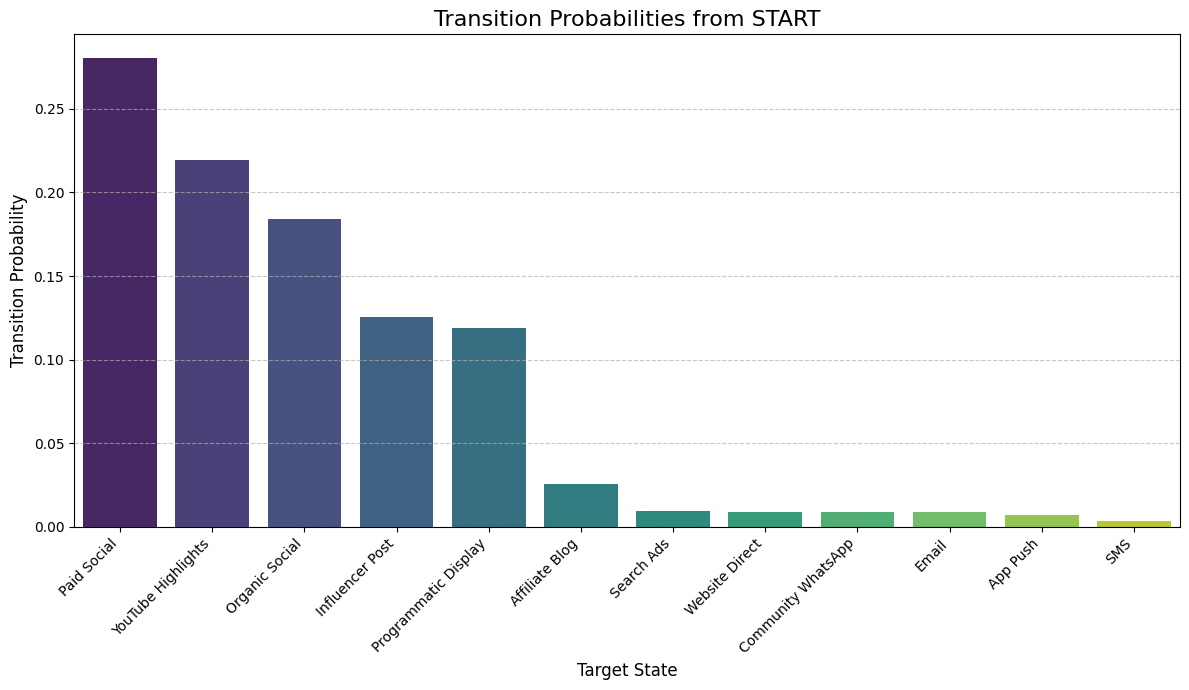

In [11]:
source_state = 'START' # You can change this to any other state like 'Email', 'Search Ads', etc.

if source_state in transition_matrix.index:
    # Get the row of probabilities for the chosen source state
    transition_probs = transition_matrix.loc[source_state]

    # Filter out transitions with zero probability and the source state itself
    filtered_probs = transition_probs[transition_probs > 0]

    if not filtered_probs.empty:
        # Sort for better visualization
        filtered_probs = filtered_probs.sort_values(ascending=False)

        plt.figure(figsize=(12, 7))
        sns.barplot(x=filtered_probs.index, y=filtered_probs.values, palette='viridis')
        plt.title(f'Transition Probabilities from {source_state}', size=16)
        plt.xlabel('Target State', size=12)
        plt.ylabel('Transition Probability', size=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No transitions with probability > 0 from {source_state}.")
else:
    print(f"Source state '{source_state}' not found in the transition matrix.")